# 01 - Swim data ingestion and cleaning


# Project paths and real data source


## 1) Imports and shared paths

This notebook reads the real GoSwim export from `data/raw/go-swim-export.json` and prepares CSV-style swim training tables for later notebooks.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


In [ ]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_SWIM_EXPORT = RAW_DIR / "go-swim-export.json"
print("Project root:", ROOT)
print("Raw swim export:", RAW_SWIM_EXPORT)


## 2) Normalize incoming column names

Different CSV/JSON exports use slightly different names for the same idea. standardize_columns maps these alternatives to one internal schema.

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [2]:
COLUMN_ALIASES = {
    "workout_uuid": ["workout_uuid", "uuid", "id", "workout_id", "Workout UUID"],
    "date": ["date", "start_date", "startDate", "Start Date", "start_at", "start"],
    "end_date": ["end_date", "endDate", "End Date", "end_at", "end"],
    "duration_min": ["duration_min", "duration_minutes", "Duration Minutes", "duration"],
    "duration_sec": ["duration_sec", "duration_seconds", "Duration Seconds"],
    "distance_m": ["distance_m", "Distance (m)", "distance", "total_distance_m", "swim_distance_m"],
    "distance_yd": ["distance_yd", "Distance (yd)", "yards", "total_distance_yd"],
    "stroke_count": ["stroke_count", "strokes", "Swimming Stroke Count", "swimmingStrokeCount"],
    "avg_hr": ["avg_hr", "average_heart_rate", "Average Heart Rate", "avgHeartRate"],
    "max_hr": ["max_hr", "maximum_heart_rate", "Max Heart Rate", "maxHeartRate"],
    "active_calories": ["active_calories", "active_energy_kcal", "Active Energy", "calories"],
    "swolf": ["swolf", "SWOLF", "avg_swolf", "average_swolf"],
    "pool_length_m": ["pool_length_m", "Pool Length (m)", "lap_length_m", "lapLength"],
    "location_type": ["location_type", "swimming_location_type", "Swimming Location", "location"],
    "stroke_style": ["stroke_style", "stroke", "Swimming Stroke Style", "style"],
}

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename known alternative column names to a standard schema."""
    df = df.copy()
    reverse = {}
    for standard, aliases in COLUMN_ALIASES.items():
        for a in aliases:
            reverse[a] = standard
    rename = {c: reverse[c] for c in df.columns if c in reverse}
    return df.rename(columns=rename)


## 3) Load optional CSV exports

If data/workouts.csv exists, use it first to keep notebook runs fast and deterministic.

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [3]:
def read_csv_optional(filename: str) -> pd.DataFrame:
    candidates = [DATA_DIR / filename, DATA_DIR / "csv" / filename]
    for path in candidates:
        if path.exists():
            return standardize_columns(pd.read_csv(path))
    return pd.DataFrame()


## 4) Parse raw JSON export into a CSV-style DataFrame

This section is the JSON-specific ingestion path. It is intentionally isolated for learning and debugging.

The goal is to flatten each raw workout object into one dataframe row:

$$
\text{raw workout JSON} \rightarrow \text{one CSV-style workout row}
$$

Code-style implementation:

```python
rows.append({
    "workout_uuid": w.get("id"),
    "date": w.get("startDate"),
    "duration_sec": duration_sec,
    "distance_m": distance_m,
})
```

Expected output is still one row per workout with standard columns such as `date`, `distance_m`, `duration_sec`, `avg_hr`, and `stroke_count`.

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [4]:
def resolve_raw_export_path(raw_json_path=None):
    """Resolve a raw JSON export path from a specific file or the latest one in data/raw."""
    if raw_json_path:
        path = Path(raw_json_path)
        if not path.exists():
            raise FileNotFoundError(f"Raw JSON export not found: {path}")
        return path

    raw_dir = DATA_DIR / "raw"
    preferred = raw_dir / "go-swim-export.json"
    if preferred.exists():
        return preferred
    if not raw_dir.exists():
        return None

    candidates = sorted(raw_dir.glob("go-swim-export-*.json"))
    if candidates:
        return candidates[-1]

    all_json = list(raw_dir.glob("*.json"))
    if not all_json:
        return None
    return max(all_json, key=lambda p: p.stat().st_mtime)


def _coerce_float(value):
    try:
        if value is None:
            return np.nan
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _infer_stroke_count(stroke_summaries):
    if not isinstance(stroke_summaries, list):
        return np.nan
    total = 0.0
    for item in stroke_summaries:
        if not isinstance(item, dict):
            continue
        count = item.get("count", item.get("strokeCount"))
        if count is None:
            continue
        total += _coerce_float(count)
    return total if total > 0 else np.nan


def read_json_export_to_csv_style_df(raw_json_path=None) -> pd.DataFrame:
    """Read a raw iOS/GoSwim JSON export and return a CSV-style dataframe."""
    path = resolve_raw_export_path(raw_json_path)
    if path is None:
        return pd.DataFrame()

    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    if isinstance(payload, list):
        workouts_raw = payload
    elif isinstance(payload, dict):
        workouts_raw = payload.get("workouts", [])
    else:
        workouts_raw = []

    rows = []
    for w in workouts_raw:
        if not isinstance(w, dict):
            continue

        duration_sec = w.get("durationSeconds")
        if duration_sec is None:
            duration_sec = w.get("duration")

        distance_m = w.get("distanceMeters")
        if distance_m is None:
            distance_m = w.get("distance")

        pool_length_m = w.get("poolLengthMeters")
        if pool_length_m is None:
            pool_length_m = w.get("poolLength")

        stroke_count = w.get("strokeCount")
        if stroke_count is None:
            stroke_count = _infer_stroke_count(w.get("strokeSummaries"))

        heart_rate = w.get("heartRate", {})
        if isinstance(heart_rate, dict):
            avg_hr = heart_rate.get("avg")
            if avg_hr is None:
                avg_hr = heart_rate.get("average")
                if avg_hr is None:
                    avg_hr = heart_rate.get("averageHeartRate")

            max_hr = heart_rate.get("max")
            if max_hr is None:
                max_hr = heart_rate.get("maximum")
                if max_hr is None:
                    max_hr = heart_rate.get("maximumHeartRate")

            min_hr = heart_rate.get("min")
            if min_hr is None:
                min_hr = heart_rate.get("minimum")
                if min_hr is None:
                    min_hr = heart_rate.get("minimumHeartRate")
        else:
            avg_hr = w.get("avg_hr")
            max_hr = w.get("max_hr")
            min_hr = w.get("min_hr")

        rows.append({
            "workout_uuid": w.get("workout_uuid") or w.get("uuid") or w.get("id") or w.get("workout_id"),
            "date": w.get("startDate"),
            "end_date": w.get("endDate"),
            "duration_sec": _coerce_float(duration_sec),
            "duration_min": _coerce_float(duration_sec) / 60 if duration_sec is not None else np.nan,
            "swim_time_sec": _coerce_float(w.get("totalSwimTimeSeconds")),
            "rest_time_sec": _coerce_float(w.get("totalRestTimeSeconds")),
            "distance_m": _coerce_float(distance_m),
            "stroke_count": _coerce_float(stroke_count),
            "avg_hr": _coerce_float(avg_hr),
            "max_hr": _coerce_float(max_hr),
            "min_hr": _coerce_float(min_hr),
            "pool_length_m": _coerce_float(pool_length_m),
            "location_type": w.get("locationType") or w.get("location"),
            "stroke_style": w.get("strokeStyle") or w.get("swimStrokeStyle")
        })

    return pd.DataFrame(rows)


def read_raw_json_export(raw_json_path=None) -> pd.DataFrame:
    """Backward-compatible name for the same JSON loader."""
    return read_json_export_to_csv_style_df(raw_json_path)


## 5) Synthetic data fallback generators

These keep the notebook runnable before real exports are present, while you are iterating on feature engineering.

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [5]:
def load_workouts(raw_json_path=None) -> pd.DataFrame:
    """Load workouts from CSV first, then raw JSON, then synthetic fallback."""
    csv_workouts = read_csv_optional("workouts.csv")
    if not csv_workouts.empty:
        print("Loaded workouts from data/workouts.csv")
        return csv_workouts

    raw_workouts = read_raw_json_export(raw_json_path)
    if not raw_workouts.empty:
        print(f"Loaded workouts from {resolve_raw_export_path(raw_json_path)}")
        return raw_workouts

    return pd.DataFrame()


def generate_synthetic_workouts(n_weeks=56, seed=12) -> pd.DataFrame:
    """Create realistic-enough swim-session data for demonstration and testing."""
    rng = np.random.default_rng(seed)
    rows = []
    start = pd.Timestamp.today().normalize() - pd.Timedelta(weeks=n_weeks)
    workout_id = 0
    for week in range(n_weeks):
        sessions = int(rng.choice([2, 3, 3, 4, 4, 5], p=[.10, .25, .25, .20, .15, .05]))
        for s in range(sessions):
            workout_id += 1
            date = start + pd.Timedelta(weeks=week, days=int(rng.integers(0, 7)))
            base_distance = 1400 + 18*week + rng.normal(0, 350)
            distance_m = max(500, base_distance)
            true_pace = 118 - 0.20*week + 9*np.exp(-week/12) + rng.normal(0, 4)
            duration_min = distance_m * true_pace / 100 / 60
            stroke_count = distance_m / max(1.15, rng.normal(1.55 + 0.003*week, 0.08))
            avg_hr = 142 + rng.normal(0, 8) - 0.03*week
            swolf = true_pace/2 + (100/(distance_m/stroke_count)) + rng.normal(0, 3)
            rows.append({
                "workout_uuid": f"synthetic-{workout_id:04d}",
                "date": date,
                "duration_min": duration_min,
                "distance_m": distance_m,
                "stroke_count": stroke_count,
                "avg_hr": avg_hr,
                "max_hr": avg_hr + rng.normal(24, 6),
                "active_calories": duration_min * rng.normal(8.5, 1.1),
                "swolf": swolf,
                "pool_length_m": rng.choice([25, 25, 25, 50]),
                "location_type": rng.choice(["pool", "pool", "pool", "open_water"], p=[.78, .10, .07, .05]),
                "stroke_style": rng.choice(["freestyle", "mixed", "backstroke", "breaststroke"], p=[.72, .18, .06, .04])
            })
    return pd.DataFrame(rows)


### Code cell note

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [6]:
def generate_synthetic_races(workouts: pd.DataFrame, seed=22) -> pd.DataFrame:
    """Create a companion synthetic race-results table for exploratory plots."""
    rng = np.random.default_rng(seed)
    w = workouts.copy()
    w["date"] = pd.to_datetime(w["date"])
    start, end = w["date"].min(), w["date"].max()
    race_dates = pd.date_range(start + pd.Timedelta(weeks=8), end - pd.Timedelta(weeks=2), periods=12)
    events = ["50 free", "100 free", "200 free", "500 free"]
    base_times = {"50 free": 29.5, "100 free": 64.0, "200 free": 142.0, "500 free": 390.0}
    rows = []
    for i, d in enumerate(race_dates):
        event = events[i % len(events)]
        days = (d - start).days
        improvement = 0.025 * days
        noise = rng.normal(0, base_times[event] * 0.018)
        time_sec = base_times[event] - improvement + noise
        rows.append({
            "race_date": d,
            "event": event,
            "stroke": "freestyle",
            "race_time_sec": time_sec,
            "pool_course": "SCY",
            "meet_name": f"Synthetic Meet {i+1}"
        })
    return pd.DataFrame(rows)


## 6) Final load + feature engineering

This final cell ties ingestion and transformation together to create `workouts` for downstream analysis.

The main pace calculation converts total workout duration and distance into seconds per 100 meters:

$$
\text{pace}_{100m} = \frac{\text{duration seconds}}{\text{distance meters}} \times 100
$$

Code-style implementation:

```python
workouts["pace_sec_per_100m"] = workouts["duration_sec"] / workouts["distance_m"] * 100
```

Stroke efficiency is measured as distance per stroke:

$$
\text{distance per stroke} = \frac{\text{distance meters}}{\text{stroke count}}
$$

Code-style implementation:

```python
workouts["distance_per_stroke_m"] = workouts["distance_m"] / workouts["stroke_count"]
```

Stroke rate per 100 meters is the reverse view:

$$
\text{strokes per }100m = \frac{\text{stroke count}}{\text{distance meters}} \times 100
$$

Code-style implementation:

```python
workouts["strokes_per_100m"] = workouts["stroke_count"] / workouts["distance_m"] * 100
```

**Expected output:** The cell should define reusable helper logic. The main thing to interpret is that later cells can call the function consistently.


In [ ]:
def prepare_workouts(workouts: pd.DataFrame) -> pd.DataFrame:
    workouts = standardize_columns(workouts)
    if workouts.empty:
        workouts = generate_synthetic_workouts()
        print("No data/workouts.csv found. Using synthetic demo workouts.")

    workouts["date"] = pd.to_datetime(workouts["date"], errors="coerce")
    workouts = workouts.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    if "distance_m" not in workouts.columns and "distance_yd" in workouts.columns:
        workouts["distance_m"] = pd.to_numeric(workouts["distance_yd"], errors="coerce") * 0.9144
    for col in ["distance_m", "duration_min", "duration_sec", "swim_time_sec", "rest_time_sec", "stroke_count", "avg_hr", "max_hr", "active_calories", "swolf"]:
        if col in workouts.columns:
            workouts[col] = pd.to_numeric(workouts[col], errors="coerce")

    if "duration_min" not in workouts.columns and "duration_sec" in workouts.columns:
        workouts["duration_min"] = workouts["duration_sec"] / 60

    workouts["duration_sec"] = workouts.get("duration_sec", workouts["duration_min"] * 60)
    pace_duration_sec = workouts["swim_time_sec"] if "swim_time_sec" in workouts.columns and workouts["swim_time_sec"].notna().any() else workouts["duration_sec"]
    workouts["pace_sec_per_100m"] = pace_duration_sec / workouts["distance_m"] * 100
    workouts["distance_per_stroke_m"] = workouts["distance_m"] / workouts["stroke_count"]
    workouts["strokes_per_100m"] = workouts["stroke_count"] / workouts["distance_m"] * 100
    workouts["week_start"] = workouts["date"].dt.to_period("W").dt.start_time
    workouts["month"] = workouts["date"].dt.to_period("M").astype(str)
    workouts["quarter_index"] = pd.qcut(workouts["date"].rank(method="first"), 4, labels=["Q1", "Q2", "Q3", "Q4"])
    return workouts

workouts = prepare_workouts(load_workouts())
display(workouts.head(3))
display(workouts.tail(3))


## Examine the available columns

A first data-analysis habit is to inspect the structure before calculating statistics. Different HealthKit export apps may use different column labels or units.

The main unit-normalized fields used throughout this project are:

$$
\text{pace}_{100m} = \frac{\text{duration seconds}}{\text{distance meters}} \times 100
$$

$$
\text{distance per stroke} = \frac{\text{distance meters}}{\text{stroke count}}
$$

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [8]:
print("Rows:", len(workouts))
print("Columns:")
print(workouts.columns.tolist())
display(workouts.describe(include="all").T.head(3))
display(workouts.describe(include="all").T.tail(3))

Rows: 483
Columns:
['workout_uuid', 'date', 'end_date', 'duration_sec', 'duration_min', 'swim_time_sec', 'rest_time_sec', 'distance_m', 'stroke_count', 'avg_hr', 'max_hr', 'min_hr', 'pool_length_m', 'location_type', 'stroke_style', 'pace_sec_per_100m', 'distance_per_stroke_m', 'strokes_per_100m', 'week_start', 'month', 'quarter_index']


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
workout_uuid,483,483,1A6D6769-FA01-4DD2-AD1D-54AAF0C7DCBB,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,483,NaN,NaN,NaN,2025-06-09 22:08:22.530020+00:00,2024-05-31 23:13:14+00:00,2024-11-30 07:40:18.500000+00:00,2025-06-11 00:12:18+00:00,2025-12-15 08:43:10.500000+00:00,2026-06-17 14:08:13+00:00,NaN
end_date,483,483,2024-06-01T01:20:43Z,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
week_start,483,NaN,NaN,NaN,2025-06-06 18:05:13.043478,2024-05-27 00:00:00,2024-11-25 00:00:00,2025-06-09 00:00:00,2025-12-11 12:00:00,2026-06-15 00:00:00,NaN
month,483,26,2025-06,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quarter_index,483,4,Q1,121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing data and data quality

Apple Watch and HealthKit exports may have missing fields. For example, some workouts may not include heart rate, SWOLF, stroke style, or detailed interval records.

Missingness is measured as the percent of rows where a column is blank:

$$
\text{missing percent} = \frac{\text{missing rows}}{\text{total rows}} \times 100
$$

Code-style implementation:

```python
missing = workouts.isna().mean().mul(100)
```

This helps decide which variables are reliable enough for analysis and which should be treated cautiously.

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [9]:
missing = (
    workouts.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percent")
    .to_frame()
)
display(missing.head(3))
display(missing.tail(3))

,missing_percent
stroke_style,100.0
location_type,100.0
avg_hr,100.0


,missing_percent
week_start,0.0
month,0.0
quarter_index,0.0


## Basic filters

For fair comparisons, pool swims and open-water swims are often separated. Pool length, GPS noise, turns, and continuous open-water pacing can all affect pace.

The analysis-ready workout set keeps workouts that satisfy three conditions:

$$
\text{distance}_m \ge 300
$$

$$
40 \le \text{pace}_{100m} \le 240
$$

Code-style implementation:

```python
analysis_workouts = pool_workouts[
    (pool_workouts["distance_m"] >= 300) &
    (pool_workouts["pace_sec_per_100m"].between(40, 240))
]
```

The goal is not to hide data. It is to create a cleaner comparison group for trend and inference work.

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [10]:
pool_workouts = workouts.copy()
if "location_type" in pool_workouts.columns:
    explicit_pool = pool_workouts["location_type"].astype(str).str.lower().str.contains("pool", na=False)
    if explicit_pool.any():
        pool_workouts = pool_workouts[explicit_pool].copy()
    elif "pool_length_m" in pool_workouts.columns:
        pool_workouts = pool_workouts[pool_workouts["pool_length_m"].notna()].copy()

analysis_workouts = pool_workouts[
    (pool_workouts["distance_m"] >= 300) &
    (pool_workouts["pace_sec_per_100m"].between(40, 240))
].copy()

print("All workouts:", len(workouts))
print("Pool workouts:", len(pool_workouts))
print("Analysis-ready pool workouts:", len(analysis_workouts))
display(analysis_workouts.head(3))
display(analysis_workouts.tail(3))


All workouts: 483
Pool workouts: 470
Analysis-ready pool workouts: 452


,workout_uuid,date,end_date,duration_sec,duration_min,swim_time_sec,rest_time_sec,distance_m,stroke_count,avg_hr,...,min_hr,pool_length_m,location_type,stroke_style,pace_sec_per_100m,distance_per_stroke_m,strokes_per_100m,week_start,month,quarter_index
0,1A6D6769-FA01-4DD2-AD1D-54AAF0C7DCBB,2024-05-31 23:13:14+00:00,2024-06-01T01:20:43Z,7648.428255,127.473804,2524.342465,5124.085790,2857.500076,876.000179,NaN,...,NaN,22.86,None,None,88.340941,3.261986,30.656173,2024-05-27,2024-05,Q1
1,DE5385A3-BE3B-45D5-8B92-48B4D224193C,2024-06-01 14:53:02+00:00,2024-06-01T17:16:20Z,8598.736703,143.312278,3521.359308,5077.377395,1828.800049,1374.000201,NaN,...,NaN,22.86,None,None,192.550263,1.331004,75.131243,2024-05-27,2024-06,Q1
2,F8140883-575E-4450-8A6B-18616C596677,2024-06-03 23:34:41+00:00,2024-06-04T01:42:36Z,7675.364195,127.922737,3442.282643,4233.081552,3520.440094,1222.018177,NaN,...,NaN,22.86,None,None,97.779895,2.880841,34.712086,2024-06-03,2024-06,Q1


,workout_uuid,date,end_date,duration_sec,duration_min,swim_time_sec,rest_time_sec,distance_m,stroke_count,avg_hr,...,min_hr,pool_length_m,location_type,stroke_style,pace_sec_per_100m,distance_per_stroke_m,strokes_per_100m,week_start,month,quarter_index
480,D2A76A13-D33B-4528-BA1B-B88B4AB168DB,2026-06-16 14:04:31+00:00,2026-06-16T16:40:36Z,9365.881996,156.098033,6061.543213,3304.338783,4400.000000,1499.000737,NaN,...,NaN,50.00,None,None,137.762346,2.935289,34.068199,2026-06-15,2026-06,Q4
481,BD3DB5FA-70B0-47E1-A2A6-2BD8444D80B3,2026-06-16 23:58:51+00:00,2026-06-17T02:04:40Z,7548.692608,125.811543,2700.108629,4848.583979,2788.920074,991.000222,NaN,...,NaN,22.86,None,None,96.815561,2.814248,35.533475,2026-06-15,2026-06,Q4
482,9D87641F-2BB8-40A6-8F40-DAAAC2C6EB15,2026-06-17 14:08:13+00:00,2026-06-17T16:32:38Z,8664.157495,144.402625,5085.833871,3578.323624,5300.000000,1603.001677,NaN,...,NaN,50.00,None,None,95.959130,3.306297,30.245315,2026-06-15,2026-06,Q4


## Weekly aggregation

Many training questions work better at the week level than the individual workout level.

Weekly distance is a sum:

$$
\text{weekly volume} = \sum \text{distance}_m
$$

Code-style implementation:

```python
weekly["total_distance_m"] = analysis_workouts.groupby("week_start")["distance_m"].sum()
```

Weekly average pace is a mean:

$$
\bar{x}_{\text{pace}} = \frac{1}{n}\sum_{i=1}^{n} \text{pace}_{i}
$$

Code-style implementation:

```python
avg_pace_sec_per_100m=("pace_sec_per_100m", "mean")
```

Weekly aggregation reduces day-to-day noise and allows questions such as whether training volume increased, whether average pace changed, and whether heart-rate patterns shifted.

**Expected output:** Expect paired previews: the first 3 rows show the starting structure, and the latest 3 rows help confirm the most recent records look reasonable.


In [11]:
weekly_agg = {
    "sessions": ("workout_uuid", "count"),
    "total_distance_m": ("distance_m", "sum"),
    "avg_distance_m": ("distance_m", "mean"),
    "avg_pace_sec_per_100m": ("pace_sec_per_100m", "mean"),
    "median_pace_sec_per_100m": ("pace_sec_per_100m", "median"),
    "avg_hr": ("avg_hr", "mean"),
    "avg_distance_per_stroke_m": ("distance_per_stroke_m", "mean"),
}

if "swolf" in analysis_workouts.columns:
    weekly_agg["avg_swolf"] = ("swolf", "mean")

weekly = (
    analysis_workouts
    .groupby("week_start")
    .agg(**weekly_agg)
    .reset_index()
)

if "avg_swolf" not in weekly.columns:
    weekly["avg_swolf"] = np.nan

display(weekly.head(3))
display(weekly.tail(3))


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf
0,2024-05-27,2,4686.300125,2343.150063,140.445602,140.445602,NaN,2.296495,NaN
1,2024-06-03,4,11978.640320,2994.660080,94.599379,94.450755,NaN,2.881921,NaN
2,2024-06-10,6,22821.800079,3803.633347,115.768771,79.489092,NaN,2.696377,NaN


,week_start,sessions,total_distance_m,avg_distance_m,avg_pace_sec_per_100m,median_pace_sec_per_100m,avg_hr,avg_distance_per_stroke_m,avg_swolf
101,2026-06-01,8,23565.900345,2945.737543,136.489127,132.297215,NaN,2.647709,NaN
102,2026-06-08,4,14934.640076,3733.660019,116.752654,117.050274,NaN,2.977347,NaN
103,2026-06-15,4,15888.920074,3972.230019,118.164580,117.288954,NaN,2.922873,NaN


## First visual checks

These charts are exploratory. They show whether the data looks plausible and whether trend analysis is worth pursuing.

**Expected output:** The cell should run without errors and make the required packages, paths, or helper tools available for the rest of the notebook.


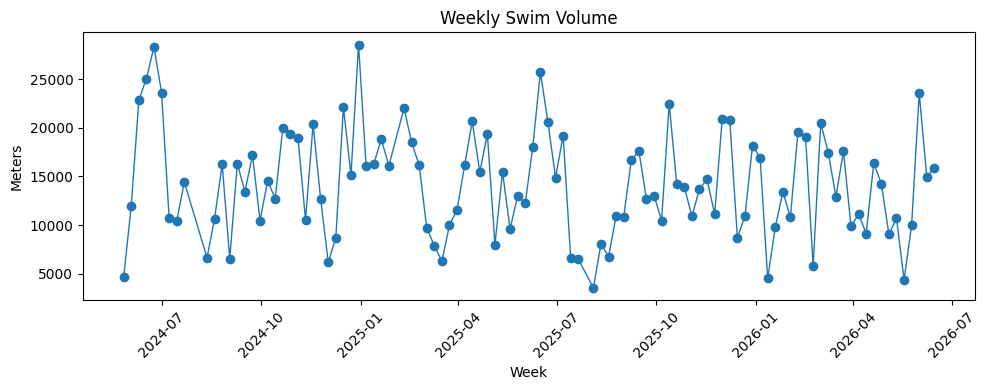

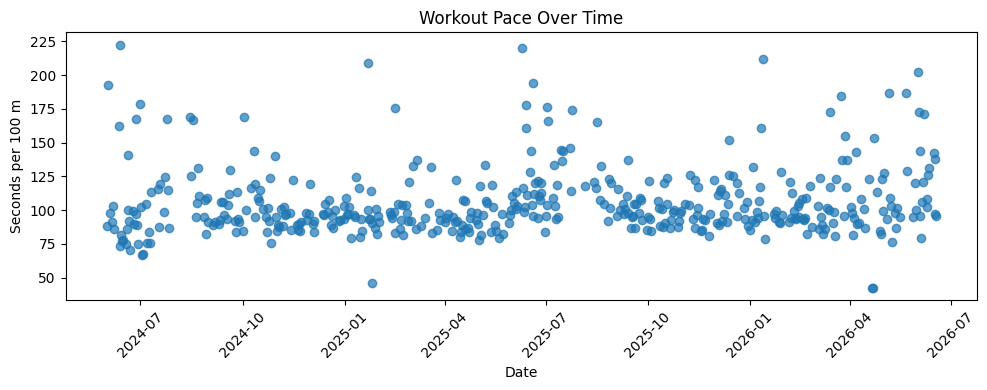

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(weekly["week_start"], weekly["total_distance_m"], marker="o", linewidth=1)
plt.title("Weekly Swim Volume")
plt.xlabel("Week")
plt.ylabel("Meters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(analysis_workouts["date"], analysis_workouts["pace_sec_per_100m"], alpha=0.7)
plt.title("Workout Pace Over Time")
plt.xlabel("Date")
plt.ylabel("Seconds per 100 m")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save cleaned outputs

The remaining notebooks can reuse these cleaned tables directly.

Prepared data flow:

$$
\text{raw export} \rightarrow \text{clean workout rows} \rightarrow \text{weekly training rows}
$$

Code-style implementation:

```python
analysis_workouts.to_csv(PROCESSED_DIR / "clean_workouts.csv", index=False)
weekly.to_csv(PROCESSED_DIR / "weekly_training.csv", index=False)
```

**Expected output:** Expect processed files or folders to be written for later notebooks and web-app views. The key interpretation is that downstream data is now prepared.


In [ ]:
workouts.to_csv(PROCESSED_DIR / "swim_workouts_csv_style.csv", index=False)
analysis_workouts.to_csv(PROCESSED_DIR / "clean_workouts.csv", index=False)
weekly.to_csv(PROCESSED_DIR / "weekly_training.csv", index=False)

print("Saved prepared swim data:")
print(PROCESSED_DIR / "swim_workouts_csv_style.csv")
print(PROCESSED_DIR / "clean_workouts.csv")
print(PROCESSED_DIR / "weekly_training.csv")
